### part1
- electric.csv
1. 케라스, tenserflow 학습
2. scatter와 예측선
3. 전기생산량 4, 5인 경우 전기사용량 예측
4. 결정계수(sklearn 이용)


In [2]:
import tensorflow as tf
from keras.optimizers import Adam
from keras import Sequential
from keras.layers import Dense,Activation
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [3]:
df=pd.read_csv('../data/electric.csv',index_col='Unnamed: 0')
df

,전기생산량,전기사용량
0,3.52,2.48
1,2.58,2.27
2,3.31,2.47
3,4.07,2.77
4,4.62,2.98
5,3.98,3.05
6,4.29,3.18
7,4.83,3.46
8,3.71,3.03
9,4.61,3.25


In [4]:
x=df.iloc[:,0].values
y=df.iloc[:,1].values

In [5]:
dense = Dense( units=1, input_dim=1)
model = Sequential( [dense]) # dense의  w와 b가 학습대상이다
model.compile( loss='mse', optimizer= Adam(0.1) )
h = model.fit( x, y, epochs=500)

Epoch 1/500


c:\Users\Dell5371\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 27.0874
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 22.2049
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 17.8237
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 13.9498
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 10.5853
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 7.7268
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 5.3647
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 3.4819
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 2.0525
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 1.0417
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.4049
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0886
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0324
Epoch 14/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1711
Epoch 15/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.4384
Epoch 16/500
1/1 ━━━━━━━━

In [6]:
y_pred=model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


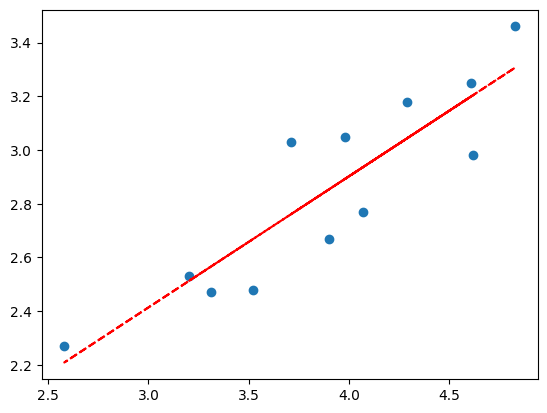

In [7]:
plt.scatter(x,y)
plt.plot( x, y_pred, 'r--')
plt.show()

In [8]:
model.predict(np.array([4,5]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


array([[2.9017463],
       [3.389725 ]], dtype=float32)

In [9]:
print(r2_score(y,y_pred))

0.7971206494958014


#### part2
- trees.csv
1. 케라스 학습
2. 예측값과 실제값 plot
3. 11.1, 80인 경우 volume 예측
4. 결정계수

In [10]:
df=pd.read_csv('../data/trees.csv')
df

,Girth,Height,Volume
0,8.3,70,10.3
1,8.6,65,10.3
2,8.8,63,10.2
3,10.5,72,16.4
4,10.7,81,18.8
5,10.8,83,19.7
6,11.0,66,15.6
7,11.0,75,18.2
8,11.1,80,22.6
9,11.2,75,19.9


In [11]:
x=df.iloc[:,:-1]
y=df.iloc[:,2]

In [12]:
class MyDense(tf.keras.layers.Layer):
    def __init__(self, units=1, input_dim1=1, input_dim2=1, **kwargs):
        super(MyDense, self).__init__(**kwargs)
        self.w1 = self.add_weight(shape=(input_dim1,), initializer="random_uniform", trainable=True, name="w1")
        self.w2 = self.add_weight(shape=(input_dim2,), initializer="random_uniform", trainable=True, name="w2")
        self.b = self.add_weight(shape=(units,), initializer="random_uniform", trainable=True, name="b")

    def call(self, inputs): 
        return self.w1 * inputs[:, 0:1] + self.w2 * inputs[:, 1:2] + self.b


In [13]:
model = Sequential( [
    MyDense(units=1),
    Dense(10, activation='relu'),
    Dense(1)

]) # dense의  w와 b가 학습대상이다
model.compile( loss='mse', optimizer= Adam(0.1) )
h = model.fit( x, y, epochs=500)

Epoch 1/500

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 855ms/step - loss: 1094.5741
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 625.0573
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 211.1084
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 593.6966
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 379.1985
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 203.5909
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 228.4627
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 307.7813
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 351.7549
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 344.9057
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 299.2178
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 238.2544
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 194.0518
Epoch 14/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 195.1246
Epoch 15/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - l

In [14]:
y_pred=model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


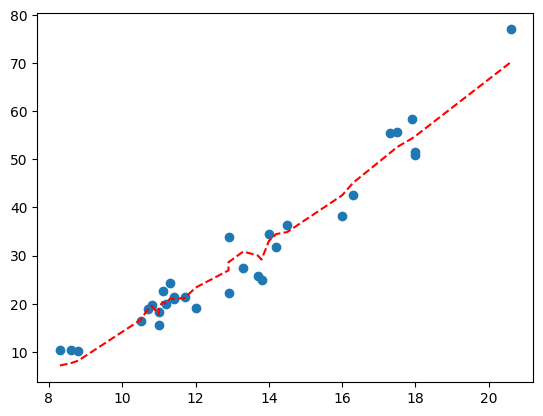

In [15]:

plt.scatter(x.iloc[:,0],y)
plt.plot( x.iloc[:,0], y_pred, 'r--')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


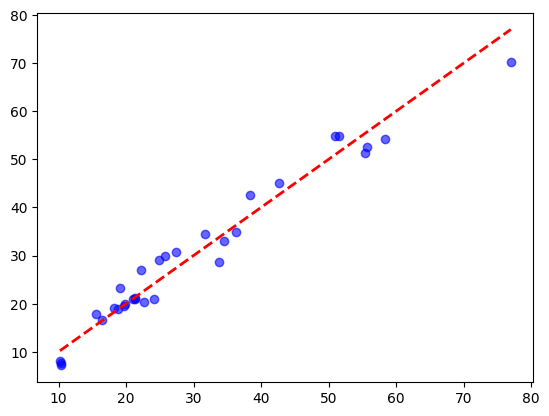

In [18]:
y_pred = model.predict(x)

plt.scatter(y, y_pred, color='blue', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', lw=2, label='Perfect Prediction')

plt.show()

In [ ]:
model.predict(np.array([[11.1, 80]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


array([[20.216234]], dtype=float32)

In [ ]:
print(r2_score(y,y_pred))

0.9414541110950885
